# Cross-Validation - Model Evaluation

Now, let's construct a reusable evaluation workflow. Rather than reporting a single score from one split, we quantify variation across folds - using confidence intervals. This helps estimate how a model may generalise to unseen data.

#### Data Loading

Let's start with a minimal dataset setup, using the same Telco Churn data. We will directly use the cleaned parquet file.

In [ ]:
# imports
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_parquet('./datasets/telco_churn_cleaned.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   object  
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   int64   
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   category
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-nu

In [3]:
# define features and target
y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["Churn", "customerID"])
X.shape, y.shape

((7032, 19), (7032,))

In [ ]:
numeric_features = X.select_dtypes(include=["int", "float"]).columns
categorical_features = X.select_dtypes(include=["category"]).columns

# setting up pipeline 
preprocess = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_features),("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
)

### Cross-Validation Harness

#### Why Confidence Intervals?

We saw that cross-validation produces a set of performance scores, not a single value. Let $(s_1, s_2, \ldots, s_k)$ denote the evaluation metrics obtained from $k$ folds.

We can estimate the mean performance and the variability across folds:

$$
\bar{s} = \frac{1}{k}\sum_{i=1}^{k}s_i
$$
$$
\sigma = \sqrt{\frac{1}{k-1}\sum_{i=1}^{k}(s_i - \bar{s})^2}
$$

To quantify uncertainty in the mean estimate, we form an approximate 95% confidence interval:

$$
\text{CI}_{95} = \bar{s} \pm t_{0.975,\space k-1}\cdot \frac{\sigma}{\sqrt{k}}
$$

(*For larger $k$, $t_{0.975,\space k-1} \approx 1.96$*)



This interval provides a plausible range for the model’s true generalisation performance based on the observed variability in cross-validation. A higher average score is meaningful only when accompanied by a narrow interval indicating low uncertainty.

Thus, we will use confidence intervals here to compare models more responsibly by considering both performance and stability.

#### Cross-Validation Evaluation Pipeline

Let's build a function to perform cross-validation and return:
- Mean performance
- Standard deviation across folds
- 95% Confidence Interval for the mean

In [ ]:
def evaluate_cv(model, X, y, metric="accuracy", cv=5):
    scores = cross_val_score(model, X, y, scoring=metric, cv=cv)    # will take in the model, scoring criteria, and CV folds
    k = len(scores)
    mean = np.mean(scores)          # mean
    std = np.std(scores, ddof=1)    # std dev (ddof=1 as we are using the sample, not whole population)
    
    t_crit = t.ppf(0.975, df=k-1)   # t critical value
    
    # confidence interval bounds
    ci_low = mean - t_crit * (std / np.sqrt(k))
    ci_high = mean + t_crit * (std / np.sqrt(k))
    
    return {"Scores": scores.astype(float), "Mean": float(mean), "std": float(std), "CI": (float(ci_low), float(ci_high))}

We will be using the evaluation harness to test the models that we are going to build

### Baseline Model Comparison

Let's start by comparing a linear model with a more flexible one

In [6]:
models = {"Logistic Regression": LogisticRegression(max_iter=1000),
          "Random Forest": RandomForestClassifier(random_state=1)}

# use a pipeline to run the evaluate_cv function on both models
results = {name: evaluate_cv(Pipeline([("preprocess", preprocess), ("clf", model)]), X, y) for name, model in models.items()}
results

{'Logistic Regression': {'Scores': array([0.80170576, 0.81236674, 0.79231863, 0.80796586, 0.8029872 ]),
  'Mean': 0.8034688374829774,
  'std': 0.007534309922403663,
  'CI': (0.7941137561010193, 0.8128239188649354)},
 'Random Forest': {'Scores': array([0.7960199 , 0.78749112, 0.76742532, 0.79445235, 0.79516358]),
  'Mean': 0.7881104536249863,
  'std': 0.012049729764192342,
  'CI': (0.7731487379887043, 0.8030721692612683)}}

*(Again, the recall here will not match the accuracy due to class imbalance issues. You are encouraged to try out resampling strategies)*

To interpret these results more effectively, it is helpful to consider the distribution of performance across folds visually. Let's try plotting the mean accuracy for each model together with error bars that reflect the variation observed during cross-validation.

This allows us to assess both how well each model performs on average and how consistently that performance is achieved across different subsets of the data.

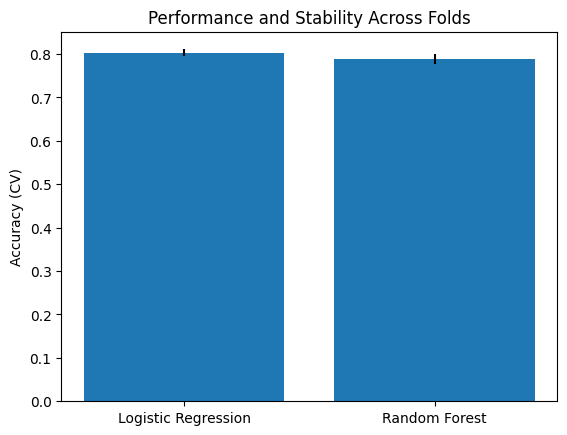

In [7]:
names = list(results.keys())
means = [results[m]["Mean"] for m in names]
stds = [results[m]["std"] for m in names]

plt.bar(names, means, yerr=stds)
plt.ylabel("Accuracy (CV)")
plt.title("Performance and Stability Across Folds")
plt.show()

The two models show very similar mean CV accuracy values, and the error bars (representing the variability across folds) are. This overlap suggests that the apparent difference in average performance is not statistically meaningful based on the evidence from cross-validation. Note that these scores are only the CV scores; we have not performed a proper train-test split for evaluation.

Thus, the increased model complexity of the Random Forest does not provide a reliably better generalisation performance compared to Logistic Regression on this dataset. At this stage, selecting the simpler model would be equally justified from a performance and stability standpoint - recall Occam's razor.